In [26]:
%load_ext autoreload
%autoreload 2

['imgname', 'center', 'scale', 'pose_cam', 'pose_world', 'shape', 'trans_cam', 'trans_world', 'gtkps', 'cam_int', 'cam_ext', 'gender', 'proj_verts', 'serno', 'lbs_model_params', 'identity_coeffs', 'face_expr_coeffs', 'mhr_keypoints_2d']
(22021, 2) (22021,)
torch.Size([1, 4, 4])
torch.Size([1, 3])
torch.Size([1, 127, 3])


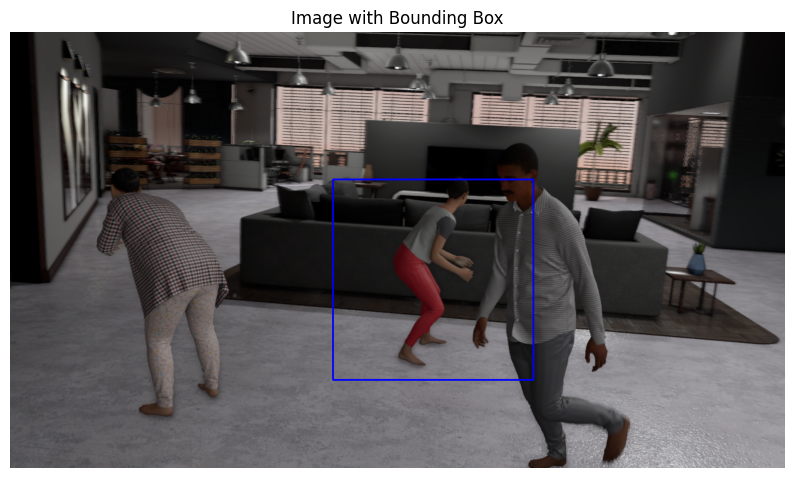

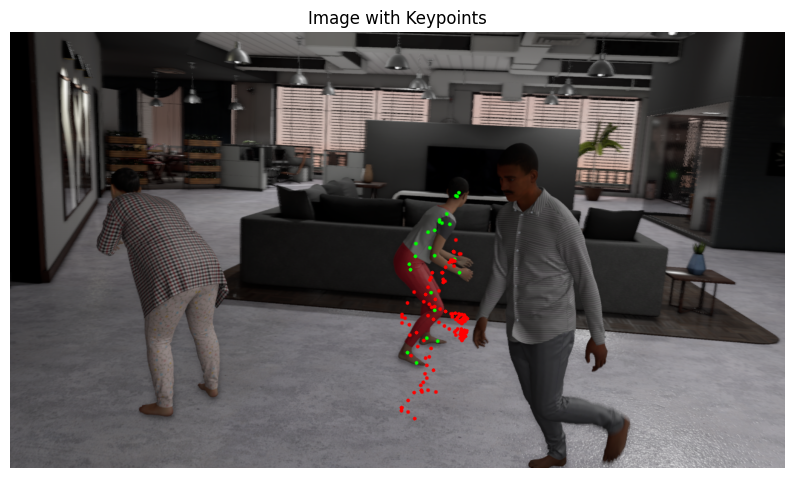

: 

In [ ]:
import cv2 
import os 
import torch

import numpy as np

BEDLAM_PATH = "/scratch/cq244/BEDLAM/data/"

PATH = "/scratch/cq244/BEDLAM/data/training_labels/all_npz_12_training_extra_mhr/20221013_3_250_batch01hand_orbit_bigOffice_6fps.npz"
data = np.load(PATH)
print(list(data.keys()))
print(data['center'].shape, data['scale'].shape)
index = 100

device = "cuda" if torch.cuda.is_available() else "cpu"
mhr_model = torch.jit.load(
    "/scratch/cq244/sam-3d-body/checkpoints/sam-3d-body-dinov3/assets/mhr_model.pt",
    map_location=device,
).to(device)

mhr_output = mhr_model(
    identity_coeffs=torch.from_numpy(data['identity_coeffs'][[index]]).to(device),
    model_parameters=torch.from_numpy(data['lbs_model_params'][[index]]).to(device),
    face_expr_coeffs=torch.from_numpy(data['face_expr_coeffs'][[index]]).to(device),
    apply_correctives=True,
)
mhr_verts, mhr_skeleton_state = mhr_output # 127, 8
mhr_j3d = mhr_skeleton_state[..., :3] 
mhr_verts /= 100.0
mhr_j3d /= 100.0


cam_int = torch.from_numpy(data['cam_int'][[index]]).to(device)
cam_ext = torch.from_numpy(data['cam_ext'][[index]]).to(device) 
print(cam_ext.shape)
trans_cam = cam_ext[:, :3, 3]
print(trans_cam.shape)
print(mhr_j3d.shape)

def project(points, cam_trans, cam_int):
    points = points + cam_trans
    projected_points = points / points[..., -1].unsqueeze(-1)
    projected_points = torch.einsum('bij, bkj->bki', cam_int, projected_points)
    return projected_points

mhr_j2d_full = project(mhr_j3d, trans_cam.unsqueeze(1), cam_int)[..., :2].cpu().numpy()

# mhr_j2d_full = data['mhr_keypoints_2d'][[index]]



center, scale = data['center'][index], data['scale'][index]
scale *= 200

bbox_size = scale
# Calculate top-left and bottom-right coordinates
x1 = int(round(center[0] - bbox_size / 2))
y1 = int(round(center[1] - bbox_size / 2))
x2 = int(round(center[0] + bbox_size / 2))
y2 = int(round(center[1] + bbox_size / 2))










img_path = os.path.join("/scratch/cq244/BEDLAM/data/training_images/20221013_3_250_batch01hand_orbit_bigOffice_6fps/png", data['imgname'][index])

img  = cv2.imread(img_path)

gtkps = data['gtkps'][index]

img_bbox_vis = img.copy()
cv2.rectangle(img_bbox_vis, (x1, y1), (x2, y2), (255, 0, 0), 2)  # blue bbox

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_bbox_vis, cv2.COLOR_BGR2RGB))
plt.title("Image with Bounding Box")
plt.axis('off')
plt.show()

# Visualize the first set of keypoints (x, y) on the image
import matplotlib.pyplot as plt

img_vis = img.copy()
kps_xy = gtkps[:24, :2]  # shape: (70, 2), x,y pixel coordinates
mhr_kps_xy = mhr_j2d_full[0]
for x, y in kps_xy:
    x_int, y_int = int(round(x)), int(round(y))
    cv2.circle(img_vis, (x_int, y_int), 3, (0, 255, 0), -1)  # green dots

for x, y in mhr_kps_xy:
    x_int, y_int = int(round(x)), int(round(y))
    cv2.circle(img_vis, (x_int, y_int), 3, (0, 0, 255), -1)  # red dots



plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.title("Image with Keypoints")
plt.axis('off')
plt.show()
    
    

In [18]:

# Debug visualization: compare MHR projected joints vs ground truth keypoints
if seq_idx == 1:
    # Get ground truth keypoints for this batch
    gtkps_batch = original_data['gtkps'][original_indices]  # B, num_joints, 2 or 3
    gtkps_batch_2d = gtkps_batch[..., :2]  # B, num_joints, 2
    imgnames_batch = original_data['imgname'][original_indices]  # B,
    
    # Visualize single frame
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    
    # Base image directory - npz filename (without extension) specifies the directory name
    # imgname format is typically like 'seq_000000/seq_000000_0000.png'
    image_base_dir = '/scratch/cq244/BEDLAM/data/training_images'  # Base directory for training images
    image_dir = os.path.join(image_base_dir, npz_name, 'png')  # npz_name/png is the directory path
    
    # Visualize first frame
    vis_idx = 0
    frame_idx = original_indices[vis_idx]
    
    # Get projected MHR joints and GT keypoints for this frame
    mhr_kp2d = mhr_joints_2d_batch[vis_idx]  # num_joints, 2
    gt_kp2d = gtkps_batch_2d[vis_idx]  # num_joints, 2
    imgname = imgnames_batch[vis_idx]
    
    # Construct image path: base_dir/npz_name/png/imgname
    image_path = os.path.join(image_dir, imgname)
    if os.path.exists(image_path):
        # Load image using cv2 (BGR format)
        img = cv2.imread(image_path)
        if img is not None:
            # Convert BGR to RGB for matplotlib
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            # Display image
            ax.imshow(img_rgb)
        else:
            # If image can't be loaded, use white background
            ax.set_facecolor('white')
    else:
        # If image path doesn't exist, use white background
        ax.set_facecolor('white')
        print(f'[Device {self._device}] Warning: Image not found at {image_path}')
    
    # Plot ground truth keypoints in blue
    ax.scatter(gt_kp2d[:, 0], gt_kp2d[:, 1], c='blue', s=10, alpha=0.8, label='GT Keypoints', marker='o', edgecolors='cyan', linewidths=1)
    
    # Plot MHR projected joints in red
    ax.scatter(mhr_kp2d[:, 0], mhr_kp2d[:, 1], c='red', s=10, alpha=0.8, label='MHR Joints', marker='x', linewidths=2)
    
    # Draw lines connecting corresponding points to show error
    # for j in range(min(len(mhr_kp2d), len(gt_kp2d))):
    #     ax.plot([gt_kp2d[j, 0], mhr_kp2d[j, 0]], 
    #             [gt_kp2d[j, 1], mhr_kp2d[j, 1]], 
    #             'g-', alpha=0.3, linewidth=0.5)
    
    # Compute and display error statistics
    # if len(mhr_kp2d) == len(gt_kp2d):
    #     errors = np.linalg.norm(mhr_kp2d - gt_kp2d, axis=1)
    #     mean_error = np.mean(errors)
    #     max_error = np.max(errors)
    #     ax.set_title(f'Frame {frame_idx}\nMean Error: {mean_error:.2f}px, Max: {max_error:.2f}px', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    # else:
    #     ax.set_title(f'Frame {frame_idx}\nJoint count mismatch', color='white', bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
    
    ax.set_xlabel('X (pixels)')
    ax.set_ylabel('Y (pixels)')
    ax.legend(loc='upper right')
    ax.set_aspect('equal')  # Set equal aspect ratio for correct proportions
    
    plt.tight_layout()
    os.makedirs('./debug_vis', exist_ok=True)
    debug_path = os.path.join('./debug_vis', f'{npz_name}_serno_{serno_value}_joints_comparison.png')
    plt.savefig(debug_path, dpi=150)
    plt.close(fig)
    print(f'[Device {self._device}] Saved debug visualization to {debug_path}')
    
    # 3D visualization of vertices: SMPL vs MHR
    fig_3d = plt.figure(figsize=(12, 12))
    ax_3d = fig_3d.add_subplot(111, projection='3d')
    
    # Get vertices for the first frame
    smpl_verts_frame = smpl_vertices[vis_idx]  # num_verts, 3
    mhr_verts_frame = converted_vertices[vis_idx] / 100.0  # num_verts, 3 (convert from cm to m)
    smpl_verts_frame[..., [1, 2]] *= -1
    mhr_verts_frame[..., [1, 2]] *= -1
    
    # Get joints for the first frame
    smpl_joints_frame = smpl_output.joints[vis_idx].detach().cpu().numpy()  # num_joints, 3
    mhr_joints_frame = mhr_joints_3d[vis_idx]  # num_joints, 3 (already divided by 100)
    smpl_joints_frame[..., [1, 2]] *= -1
    mhr_joints_frame[..., [1, 2]] *= -1
    
    # Plot SMPL vertices in blue
    ax_3d.scatter(smpl_verts_frame[:, 0], smpl_verts_frame[:, 1], smpl_verts_frame[:, 2], 
                    c='blue', s=1, alpha=0.5, label='SMPL Vertices')
    
    # Plot MHR vertices in red
    ax_3d.scatter(mhr_verts_frame[:, 0], mhr_verts_frame[:, 1], mhr_verts_frame[:, 2], 
                    c='red', s=1, alpha=0.5, label='MHR Vertices')
    
    # Plot SMPL joints in cyan with larger markers
    ax_3d.scatter(smpl_joints_frame[:, 0], smpl_joints_frame[:, 1], smpl_joints_frame[:, 2], 
                    c='cyan', s=30, alpha=0.8, label='SMPL Joints', marker='o', edgecolors='blue', linewidths=1)
    
    # Plot MHR joints in magenta with larger markers
    ax_3d.scatter(mhr_joints_frame[:, 0], mhr_joints_frame[:, 1], mhr_joints_frame[:, 2], 
                    c='magenta', s=30, alpha=0.8, label='MHR Joints', marker='x', linewidths=2)
    
    # Set equal aspect ratio for proper 3D visualization
    # Get the limits for all vertices and joints combined
    all_verts = np.vstack([smpl_verts_frame, mhr_verts_frame, smpl_joints_frame, mhr_joints_frame])
    x_limits = all_verts[:, 0].min(), all_verts[:, 0].max()
    y_limits = all_verts[:, 1].min(), all_verts[:, 1].max()
    z_limits = all_verts[:, 2].min(), all_verts[:, 2].max()
    
    # Calculate the range for each axis
    max_range = np.array([
        x_limits[1] - x_limits[0],
        y_limits[1] - y_limits[0],
        z_limits[1] - z_limits[0]
    ]).max() / 2.0
    
    # Calculate the center for each axis
    mid_x = (x_limits[0] + x_limits[1]) * 0.5
    mid_y = (y_limits[0] + y_limits[1]) * 0.5
    mid_z = (z_limits[0] + z_limits[1]) * 0.5
    
    # Set equal limits for all axes
    ax_3d.set_xlim(mid_x - max_range, mid_x + max_range)
    ax_3d.set_ylim(mid_y - max_range, mid_y + max_range)
    ax_3d.set_zlim(mid_z - max_range, mid_z + max_range)
    
    # Set equal aspect ratio (this is the key for proper 3D visualization)
    ax_3d.set_box_aspect([1, 1, 1])  # Equal aspect ratio for all axes
    
    ax_3d.set_xlabel('X')
    ax_3d.set_ylabel('Y')
    ax_3d.set_zlabel('Z')
    ax_3d.legend()
    ax_3d.set_title(f'Frame {frame_idx}: SMPL vs MHR Vertices & Joints (3D)')
    
    # Set viewing angle
    ax_3d.view_init(elev=10, azim=20, vertical_axis='y')
    
    plt.tight_layout()
    debug_path_3d = os.path.join('./debug_vis', f'{npz_name}_serno_{serno_value}_vertices_3d.png')
    plt.savefig(debug_path_3d, dpi=150)
    plt.close(fig_3d)
    print(f'[Device {self._device}] Saved 3D vertices visualization to {debug_path_3d}')
    
    break

(150841, 127)
1.0 1.0
(71947, 127)
1.0 1.0
(8455, 127)
1.0 1.0
(23222, 127)
1.0 1.0
(8776, 127)
1.0 1.0
(36846, 127)
1.0 1.0
(8951, 127)
1.0 1.0
(22305, 127)
1.0 1.0
(36310, 127)
1.0 1.0
(8271, 127)
1.0 1.0
(22737, 127)
1.0 1.0
(8420, 127)
1.0 1.0
(89728, 127)
1.0 1.0
(21938, 127)
1.0 1.0
(17541, 127)
1.0 1.0
(17110, 127)
1.0 1.0
(22021, 127)
1.0 1.0
(30894, 127)
1.0 1.0
(8790, 127)
1.0 1.0
(22214, 127)
1.0 1.0
(83009, 127)
1.0 1.0
(22569, 127)
1.0 1.0
(22978, 127)
1.0 1.0
(22623, 127)
1.0 1.0
(77362, 127)
1.0 1.0
(63556, 127)
1.0 1.0
(21825, 127)
1.0 1.0
(86605, 127)
1.0 1.0
